# Redes Convolucionales Modernas

Ahora que comprendemos los conceptos básicos del armado de las CNN, hagamos un recorrido por las arquitecturas CNN modernas. Este recorrido es, por necesidad, incompleto, gracias a la plétora de nuevos y emocionantes diseños que se agregan. Su importancia deriva del hecho de que no solo se pueden usar directamente para tareas de visión, sino que también sirven como generadores de características básicas para tareas más avanzadas como el seguimiento (tracking), la segmentación, detección de objetos o transferencia de estilos.

En este notebook, la mayoría de las secciones corresponden a una arquitectura CNN significativa que fue en algún momento (o actualmente) el modelo base sobre el cual se construyeron muchos proyectos de investigación y sistemas implementados. Cada una de estas redes fue brevemente una arquitectura dominante y muchas fueron ganadoras o finalistas en la competencia ImageNet, que ha servido como un barómetro del progreso en el aprendizaje supervisado en visión por computadora desde 2010. Solo recientemente los transformer comenzaron a desplazar a las CNN. Cubriremos este desarrollo en la segunda parte de esta clase.

Si bien la idea de las redes neuronales profundas es bastante simple (apilar un montón de capas), el rendimiento puede variar enormemente según las arquitecturas y las opciones de hiperparámetros. Las redes neuronales descritas en este capítulo son el producto de la intuición, algunos conocimientos matemáticos y mucho ensayo y error. Presentamos estos modelos en orden cronológico, en parte para transmitir un sentido de la historia para que pueda formar sus propias intuiciones sobre hacia dónde se dirige el campo y tal vez desarrollar sus propias arquitecturas. Por ejemplo, la normalización por lotes y las conexiones residuales descritas en esta clase han ofrecido dos ideas populares para entrenar y diseñar modelos profundos, las cuales también se han aplicado desde entonces a arquitecturas más allá de la visión por computadora.



## Computer Vision Pre-ImageNet

Aunque las CNN eran bien conocidas en las comunidades de visión por computadora y aprendizaje automático después de la introducción de LeNet (LeCun et al., 1995), no dominaron inmediatamente el campo. Aunque LeNet logró buenos resultados en los primeros conjuntos de datos pequeños, aún no se había establecido el rendimiento y la viabilidad de entrenar las CNN en conjuntos de datos más grandes y realistas. De hecho, durante gran parte del tiempo transcurrido entre principios de la década de 1990 y los resultados decisivos de 2012 (Krizhevsky et al., 2012), las redes neuronales a menudo fueron superadas por otros métodos de aprendizaje automático, como los métodos kernel (Schölkopf y Smola, 2002). , métodos de ensamble (Freund et al., 1996) y estimación estructurada (Taskar et al., 2004).

Para la visión por computadora, esta comparación quizás no sea del todo precisa. Es decir, aunque las entradas a las redes convolucionales consisten en valores de píxeles sin procesar o ligeramente procesados ​​(por ejemplo, centrados), los profesionales nunca introducirían píxeles sin procesar en los modelos tradicionales. En cambio, los pipelines típicos de visión por computadora consistían en una ingeniería de extracción de características manual, como SIFT (Lowe, 2004), SURF (Bay et al., 2006) y bolsas de palabras visuales (Sivic y Zisserman, 2003). En lugar de aprender las características, las características fueron diseñadas. La mayor parte del progreso provino de tener ideas más inteligentes para la extracción de características, por un lado, y una comprensión más profunda de la geometría (Hartley y Zisserman, 2000), por el otro. El algoritmo de aprendizaje a menudo pasaba a un segundo plano.



Aunque algunos aceleradores de redes neuronales estaban disponibles en la década de 1990, aún no eran lo suficientemente potentes como para crear CNN multicanal y multicapa profundas con una gran cantidad de parámetros. Por ejemplo, la GeForce 256 de NVIDIA de 1999 pudo procesar como máximo 480 millones de operaciones por segundo (MFLOP), sin ningún marco de programación significativo para operaciones más allá de los juegos. Los aceleradores actuales pueden rendir más de 300 TFLOP por dispositivo (NVIDIA's Ampere A100). Tenga en cuenta que los FLOP son operaciones de punto flotante, como multiplicaciones y sumas. Además, los conjuntos de datos aún eran relativamente pequeños: OCR con 60 000 imágenes de $28x28$ píxeles se consideró una tarea muy desafiante. A estos obstáculos se suman trucos clave para entrenar redes neuronales que incluyen heurísticas de inicialización de parámetros (Glorot y Bengio, 2010), variantes inteligentes de descenso de gradiente estocástico (Kingma y Ba, 2014), funciones de activación sin aplastamiento (Nair y Hinton, 2010), y aún faltaban técnicas de regularización efectivas (Srivastava et al., 2014).

Por lo tanto, en lugar de entrenar sistemas de extremo a extremo (del píxel a la clasificación), las canalizaciones clásicas se parecían más a esto:

* Obtener un conjunto de datos interesante. En los primeros días, estos conjuntos de datos requerían sensores costosos. Por ejemplo, el Apple QuickTake 100 de 1994 lucía una increíble resolución de 0,3 megapíxeles (VGA), capaz de almacenar hasta 8 imágenes, todo por el precio de 1000 dólares.

* Preprocesar el conjunto de datos con características hechas a mano basadas en algunos conocimientos de óptica, geometría, otras herramientas analíticas y, ocasionalmente, en los descubrimientos fortuitos de afortunados estudiantes graduados.

* Alimentar los datos a través de un conjunto estándar de extractores de características, como SIFT (transformación de características invariantes de escala) (Lowe, 2004), SURF (características robustas aceleradas) (Bay et al., 2006), o cualquier otro extractor de características diseñadas por humanos. ¡OpenCV todavía proporciona extractores SIFT hasta el día de hoy!

* Vuelque las representaciones resultantes en su clasificador favorito, probablemente un modelo lineal o método kernel, para entrenar un clasificador.

![Imgur](https://i.imgur.com/oEfNDe9.png)

Si hubiera podido hablar con investigadores de aprendizaje automático en ese momento, le habrían dicho que el aprendizaje automático era importante y hermoso. Las teorías elegantes demostraron las propiedades de varios clasificadores (Boucheron et al., 2005) y la optimización convexa (Boyd y Vandenberghe, 2004) se convirtió en el pilar para obtenerlos. El campo del aprendizaje automático era próspero, riguroso y eminentemente útil. Sin embargo, si hubiera podido hablar con un investigador de visión por computadora, escucharía una historia muy diferente. La sucia verdad del reconocimiento de imágenes, le dirían, es que las características, la geometría (Hartley y Zisserman, 2000, Hartley y Kahl, 2009) y la ingeniería, en lugar de nuevos algoritmos de aprendizaje, impulsaron el progreso. Los investigadores de visión por computadora creían justificadamente que un conjunto de datos un poco más grande o más limpio o una canalización de extracción de características ligeramente mejorada importaba mucho más para la precisión final que cualquier algoritmo de aprendizaje.

# ImageNet

Los modelos profundos con muchas capas requieren grandes cantidades de datos para entrar en el régimen en el que superan significativamente a los métodos tradicionales basados ​​en optimizaciones convexas (p. ej., métodos lineales y kernel). Sin embargo, dada la limitada capacidad de almacenamiento de las computadoras, el costo relativo de los sensores (de imágenes) y los presupuestos de investigación comparativamente más ajustados en la década de 1990, la mayoría de las investigaciones se basaron en pequeños conjuntos de datos. Numerosos artículos se basaron en la colección de conjuntos de datos de UCI, muchos de los cuales contenían solo cientos o (algunos) miles de imágenes capturadas en baja resolución y, a menudo, con un fondo artificialmente limpio.

En 2009, se lanzó el conjunto de datos de ImageNet (Deng et al., 2009), desafiando a los investigadores a aprender modelos a partir de 1 millón de ejemplos, 1000 imágenes de cada una de las 1000 categorías distintas de objetos. Las categorías mismas se basaron en los nodos de sustantivos más populares en WordNet (Miller, 1995). El equipo de ImageNet usó la búsqueda de imágenes de Google para prefiltrar grandes conjuntos de fotos candidatas para cada categoría y empleó un servicio de crowdsourcing de Amazon para confirmar si cada imagen pertenecía a la categoría asociada. Esta escala no tenía precedentes, superando a otras en más de un orden de magnitud (por ejemplo, CIFAR-100 tiene 60 000 imágenes).

![Imgur](https://i.imgur.com/cDEpuZm.png)

Otro aspecto fue que las imágenes tenían una resolución relativamente alta de $224x224$ píxeles, a diferencia del conjunto de datos TinyImages de 80 millones de tamaño $32x32$ píxeles. Esto permitió la formación de características de nivel superior. La competencia asociada, denominada Desafío de reconocimiento visual a gran escala de ImageNet (Russakovsky et al., 2015), impulsó la investigación de la visión por computadora y el aprendizaje automático, desafiando a los investigadores a identificar qué modelos funcionaron mejor a una escala mayor de lo que los académicos habían considerado previamente. Los conjuntos de datos de visión más grandes, como LAION-5B (Schuhmann et al., 2022) contienen miles de millones de imágenes con metadatos adicionales.

![Imgur](https://i.imgur.com/7MQ402c.png)

# AlexNet

Los modelos de aprendizaje profundo son consumidores voraces de ciclos de cómputo. El entrenamiento puede tomar cientos de épocas, y cada iteración requiere pasar datos a través de muchas capas de operaciones de álgebra lineal computacionalmente costosas. Esta es una de las razones principales por las que en la década de 1990 y principios de la de 2000, se preferían algoritmos simples basados ​​en objetivos convexos optimizados de manera más eficiente.

Las unidades de procesamiento gráfico (GPU) demostraron ser un cambio de juego al hacer factible el aprendizaje profundo. Estos chips se habían desarrollado durante mucho tiempo para acelerar el procesamiento de gráficos en beneficio de los juegos de computadora. En particular, se optimizaron para un alto rendimiento en productos de matriz-vector de $4x4$, que son necesarios para muchas tareas de gráficos por computadora. Afortunadamente, las matemáticas son sorprendentemente similares a las requeridas para calcular capas convolucionales. Por esa época, NVIDIA y ATI habían comenzado a optimizar las GPU para operaciones informáticas generales (Fernando, 2004), llegando incluso a comercializarlas como GPU de propósito general (GPGPU).

Volvamos a 2012. Un gran avance se produjo cuando Alex Krizhevsky e Ilya Sutskever implementaron una CNN profunda que podía ejecutarse en GPU. Se dieron cuenta de que los cuellos de botella computacionales en las CNN, las convoluciones y las multiplicaciones de matrices son operaciones que podrían paralelizarse en hardware. Utilizando dos NVIDIA GTX 580 con 3 GB de memoria, cualquiera de las cuales tenía capacidad para 1,5 TFLOP (todavía un desafío para la mayoría de las CPU una década después), implementaron convoluciones rápidas. El código cuda-convnet fue lo suficientemente bueno como para que durante varios años fuera el estándar de la industria e impulsó los primeros dos años del auge del aprendizaje profundo.

AlexNet, que empleó una CNN de 8 capas, ganó el ImageNet Large Scale Visual Recognition Challenge 2012 por un amplio margen (Russakovsky et al., 2013). Esta red demostró, por primera vez, que las características obtenidas mediante el aprendizaje pueden trascender las características diseñadas manualmente, rompiendo el paradigma anterior en visión artificial.

Las arquitecturas de AlexNet y LeNet son sorprendentemente similares, como ilustra la figura 8.1.2. Tenga en cuenta que proporcionamos una versión ligeramente optimizada de AlexNet que elimina algunas de las peculiaridades de diseño que se necesitaban en 2012 para que el modelo se ajuste a dos GPU pequeñas.

![Imgur](https://i.imgur.com/vNR46yu.png)


También existen diferencias significativas entre AlexNet y LeNet. Primero, AlexNet es mucho más profunda que el comparativamente pequeño LeNet5. AlexNet consta de ocho capas: cinco capas convolucionales, dos capas densas ocultas y una capa densa de salida. En segundo lugar, AlexNet usó ReLU en lugar de la sigmoida como función de activación. Profundicemos en los detalles a continuación.

### Arquitectura

En la primera capa de AlexNet, la forma de la ventana de convolución es
$11\times11$. Dado que las imágenes en ImageNet son ocho veces más altas y más anchas que las imágenes MNIST, los objetos en los datos de ImageNet tienden a ocupar más píxeles con más detalles visuales. En consecuencia, se necesita una ventana de convolución más grande para capturar el objeto. La forma de la ventana de convolución en la segunda capa se reduce a $5\times5$, seguida de $3\times3$. Además, después de las capas convolucionales primera, segunda y quinta, la red agrega capas de max-pooling con una forma de ventana de $3\times3$ y un stride de 2. Además, AlexNet tiene diez veces más canales de convolución que LeNet.

Después de la última capa convolucional, hay dos enormes capas densas con 4096 neuronas de salida. Estas capas requieren parámetros de modelo de casi 1 GB. Debido a la memoria limitada en las primeras GPU, la AlexNet original usaba un diseño de flujo de datos dual, de modo que cada una de sus dos GPU podría ser responsable de almacenar y calcular solo la mitad del modelo. Afortunadamente, la memoria de GPU es comparativamente abundante ahora, por lo que rara vez necesitamos dividir modelos en GPU en estos días (nuestra versión del modelo de AlexNet se desvía del paper original en este aspecto).



In [ ]:
import torch                         # Carga PyTorch, el framework general
from torch import nn                 # Importa el submódulo de capas neuronales

def init_cnn(module):
    # Si el submódulo es una capa lineal o convolucional,
    # aplica inicialización Xavier uniforme a sus pesos.
    if type(module) == nn.Linear or type(module) == nn.Conv2d:
        nn.init.xavier_uniform_(module.weight)

class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()           # Inicializa la clase base nn.Module
        self.net = nn.Sequential(    # Construye el pipeline de capas de AlexNet
            # Bloque 1: detección de patrones grandes y reducción de resolución
            nn.LazyConv2d(96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Bloque 2: más filtros y pooling
            nn.LazyConv2d(256, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Bloques 3-5: refinamiento con kernels 3x3
            nn.LazyConv2d(384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(256, kernel_size=3, padding=1), nn.ReLU(),

            # Último pooling antes de aplanar
            nn.MaxPool2d(kernel_size=3, stride=2), nn.Flatten(),

            # Clasificador totalmente conectado con dropout para regularización
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(p=0.5),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(p=0.5),

            # Capa final que produce las logits para num_classes clases
            nn.LazyLinear(num_classes)
        )
        self.net.apply(init_cnn)     # Recorre cada submódulo para inicializar sus pesos

    def forward(self, X):
        return self.net(X)           # Propaga la entrada X por todas las capas secuenciales


### Funciones de activación




Además, AlexNet cambió la función de activación sigmoidea a una función de activación ReLU más simple. Por un lado, el cálculo de la función de activación de ReLU es más sencillo. Por ejemplo, no tiene la operación de exponenciación que se encuentra en la función de activación sigmoidea. Por otro lado, la función de activación de ReLU facilita el entrenamiento del modelo cuando se utilizan diferentes métodos de inicialización de parámetros. Esto se debe a que, cuando la salida de la función de activación sigmoidea está muy cerca de 0 o 1, el gradiente de estas regiones es casi 0, por lo que el backpropagation no puede continuar actualizando algunos de los parámetros del modelo. Por el contrario, el gradiente de la función de activación de ReLU en el intervalo positivo siempre es 1. Por lo tanto, si los parámetros del modelo no se inicializan correctamente, la función sigmoidea puede obtener un gradiente de casi 0 en el intervalo positivo, por lo que el modelo no se puede entrenar de manera efectiva.

![](https://miro.medium.com/max/1400/1*XxxiA0jJvPrHEJHD4z893g.png)

### Image Augmentation

Para aumentar aún más los datos, el ciclo de entrenamiento de AlexNet agregó una gran cantidad de aumentación de imágenes, como volteo, recorte y cambios de color. Esto hace que el modelo sea más robusto y el tamaño de muestra más grande reduce efectivamente el sobreajuste.

El aumento de imágenes genera ejemplos de entrenamiento similares pero distintos después de una serie de cambios aleatorios en las imágenes de entrenamiento, lo que amplía el tamaño del conjunto de entrenamiento. Alternativamente, el aumento de la imagen puede estar motivado por el hecho de que los ajustes aleatorios de los ejemplos de entrenamiento permiten que los modelos dependan menos de ciertos atributos, mejorando así su capacidad de generalización. Por ejemplo, podemos recortar una imagen de diferentes maneras para que el objeto de interés aparezca en diferentes posiciones, reduciendo así la dependencia de un modelo de la posición del objeto. También podemos ajustar factores como el brillo y el color para reducir la sensibilidad de un modelo al color. Probablemente sea cierto que el aumento de imágenes fue indispensable para el éxito de AlexNet en ese momento. En esta sección discutiremos esta técnica ampliamente utilizada en visión artificial.

In [3]:
%matplotlib inline

import torchvision
import matplotlib.pyplot as plt
from torchvision.io import read_image
import cv2
from torchvision.io import decode_image



En nuestra investigación de los métodos comunes de aumento de imágenes, utilizaremos la siguiente imagen de $400\times 500$ como ejemplo.


In [4]:
url='https://github.com/palasatenea66/DATASETS/raw/main/output.png'
!wget $url

--2025-09-19 00:38:39--  https://github.com/palasatenea66/DATASETS/raw/main/output.png
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/palasatenea66/DATASETS/main/output.png [following]
--2025-09-19 00:38:39--  https://raw.githubusercontent.com/palasatenea66/DATASETS/main/output.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 140015 (137K) [image/png]
Saving to: ‘output.png’

output.png          100%[===================>] 136.73K  --.-KB/s    in 0.02s   

2025-09-19 00:38:39 (5.74 MB/s) - ‘output.png’ saved [140015/140015]



In [5]:
# https://pytorch.org/vision/stable//io.html

img = decode_image("output.png", mode="RGB") #leemos la imagen como tensor en RGB
print(img.dtype) # torch.uint8
print(img.shape) # torch.Size([3, 418, 351])

torch.uint8
torch.Size([3, 418, 351])


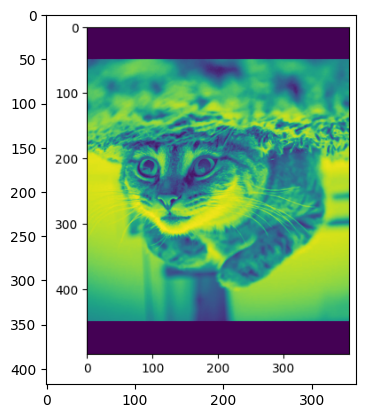

<class 'torch.Tensor'>
torch.Size([3, 418, 351])
(418, 351, 3)
(418, 351, 3)


In [6]:
#alternatica con opencv
import torchvision.transforms as T

img1 = cv2.imread('output.png') # leemos con opencv
img2 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB) # para leer en RGB
img3 = T.ToTensor()(img2) # img3 es un tensor
imgplot = plt.imshow(img2)
plt.show()
print(type(img3))
print(img3.shape)
print(img2.shape)
print(img1.shape)

La mayoría de los métodos de aumento de imágenes tienen un cierto grado de aleatoriedad. Para que nos resulte más fácil observar el efecto del aumento de imagen, a continuación definimos una función auxiliar `apply`. Esta función ejecuta el método de aumento de imagen aug varias veces en la imagen de entrada `img` y muestra todos los resultados.


In [ ]:
import matplotlib.pyplot as plt          # Motor de gráficos para crear la grilla de subplots
import torchvision.transforms as T       # Transformaciones de torchvision; aquí convierte tensores a imágenes PIL
import numpy as np                       # Trabaja con arreglos para pasar de PIL a formato compatible con matplotlib

def show(imgs):
    fig, axs = plt.subplots(             # Crea una figura con una fila y una columna por imagen
        ncols=len(imgs),
        squeeze=False)                   # squeeze=False fuerza que axs sea siempre un arreglo 2D
    for i, img in enumerate(imgs):       # Recorre cada tensor de imagen junto con su índice de columna
        img = T.ToPILImage()(img.to('cpu'))  # Asegura que el tensor esté en CPU y lo convierte a imagen PIL
        axs[0, i].imshow(np.asarray(img))    # Muestra la imagen en la celda correspondiente de la fila 0
        axs[0, i].set(                     # Elimina ticks y etiquetas para que se vea solo la imagen
            xticklabels=[], yticklabels=[],
            xticks=[], yticks=[])


In [ ]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    figsize = (num_cols * scale, num_rows * scale)  # Calcula tamaño de la figura para que las imágenes no queden diminutas
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)  # Crea una grilla de subplots con la forma deseada
    axes = axes.flatten()  # Aplana la matriz de ejes para iterar linealmente

    for i, (ax, img) in enumerate(zip(axes, imgs)):  # Asigna cada imagen al eje correspondiente
        try:
            img = T.ToPILImage()(img.to('cpu'))  # Si es un tensor, lo mueve a CPU y lo convierte en imagen PIL
        except Exception:
            pass  # Si ya es mostrable (por ejemplo, arreglo NumPy o PIL), lo deja tal cual

        ax.imshow(img)  # Muestra la imagen en el subplot
        ax.axes.get_xaxis().set_visible(False)  # Oculta el eje x para que solo se vea la imagen
        ax.axes.get_yaxis().set_visible(False)  # Oculta el eje y
        if titles:
            ax.set_title(titles[i])  # Coloca título si se proporcionó

    return axes  # Devuelve la lista de ejes por si se quiere seguir manipulando la figura


In [9]:
def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    Y = [aug(img) for _ in range(num_rows * num_cols)]
    show_images(Y, num_rows, num_cols, scale=scale)

#### Voltear y recortar

Voltear la imagen en dirección horizontal generalmente no cambia la categoría del objeto. Este es uno de los primeros y más utilizados métodos de aumento de imágenes. A continuación, usamos el módulo `transforms` de PyTorch para crear la instancia `RandomHorizontalFlip`, que voltea una imagen de izquierda a derecha con un 50 % de probabilidad.

/tmp/ipython-input-1280166944.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  apply(torch.tensor(img), T.RandomHorizontalFlip())


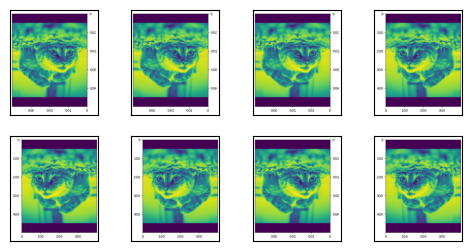

In [10]:
#img_flip = T.RandomHorizontalFlip()
#plt.imshow(img_flip(torch.tensor(img)))
apply(torch.tensor(img), T.RandomHorizontalFlip())

Voltear verticalmente no es tan común como voltear horizontalmente. Pero al menos para esta imagen de ejemplo, voltear hacia arriba y hacia abajo no dificulta el reconocimiento.


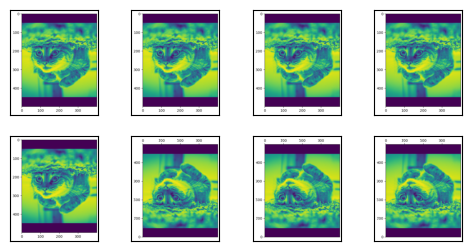

In [11]:
apply(img, T.RandomVerticalFlip())

En la imagen de ejemplo que usamos, el gato está en el medio de la imagen, pero este puede no ser el caso en general. En clases anteriores, explicamos que la capa de pooling puede reducir la sensibilidad de una capa convolucional a la posición de destino. Además, también podemos recortar aleatoriamente la imagen para que los objetos aparezcan en diferentes posiciones de la imagen a diferentes escalas, lo que también puede reducir la sensibilidad de un modelo a la posición de destino.

En el siguiente código, **recortamos al azar** una región con un área de $10\% \sim 100\%$ del área original cada vez, y la relación entre el ancho y el alto de esta área se selecciona al azar entre $0.5 \sim 2$. Luego, el ancho y el alto de la región se escalan a 200 píxeles.
A menos que se especifique lo contrario, el número aleatorio entre $a$ y $b$ en esta sección se refiere a un valor continuo obtenido por muestreo aleatorio y uniforme del intervalo $[a, b]$.


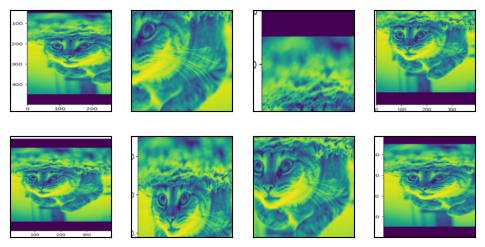

In [12]:
shape_aug = T.RandomResizedCrop(
    (200, 200), scale=(0.1, 1), ratio=(0.5, 2))
apply(img, shape_aug)

#### Cambio de colores

Otro método de aumento es el cambio de colores. Podemos cambiar cuatro aspectos del color de la imagen: brillo, contraste, saturación y tono. En el siguiente ejemplo, [**cambiamos aleatoriamente el brillo**] de la imagen a un valor entre el 50% ($1-0.5$) y el 150% ($1+0.5$) de la imagen original.


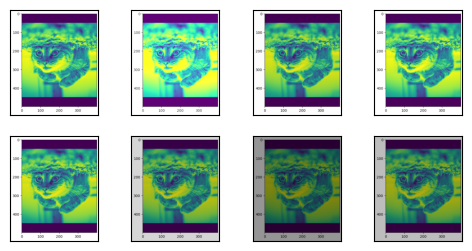

In [13]:
apply(img, T.ColorJitter(
    brightness=0.5, contrast=0, saturation=0, hue=0))

Del mismo modo, podemos **cambiar aleatoriamente el tono** de la imagen.


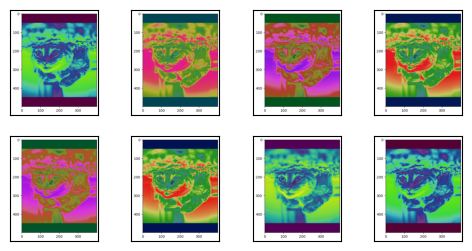

In [14]:
apply(img, T.ColorJitter(
    brightness=0, contrast=0, saturation=0, hue=0.5))

También podemos crear una instancia de RandomColorJitter y configurar cómo cambiar aleatoriamente el brillo, el contraste, la saturación y el tono de la imagen al mismo tiempo.


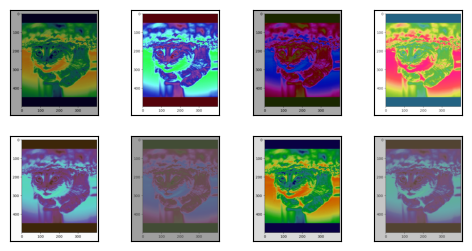

In [15]:
color_aug = T.ColorJitter(
    brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5)
apply(img, color_aug)

#### Combinación de varios métodos de aumento de imágenes

En la práctica, **combinaremos múltiples métodos de aumento de imágenes**. Por ejemplo, podemos combinar los diferentes métodos de aumento de imágenes definidos anteriormente y aplicarlos a cada imagen a través de una instancia `Compose`.

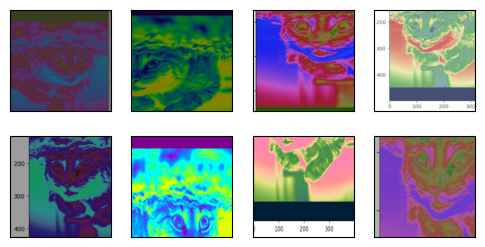

In [16]:
augs = T.Compose([T.RandomHorizontalFlip(),color_aug, shape_aug])
apply(img, augs)

### Entrenamiento

Aunque AlexNet se entrenó en ImageNet, aquí usamos Fashion-MNIST, ya que entrenar un modelo de ImageNet para la convergencia podría llevar horas o días, incluso en una GPU moderna.
Uno de los problemas de aplicar AlexNet directamente en [**Fashion-MNIST**] es que sus **imágenes tienen una resolución más baja** ($28 \times 28$ píxeles) **que las imágenes de ImageNet.**

Para hacer que las cosas funcionen, (**las agrandamos a $224 \times 224$**). Esto generalmente no es una práctica inteligente, ya que simplemente aumenta la complejidad computacional sin agregar información. No obstante, lo hacemos aquí para ser fieles a la arquitectura de AlexNet. Realizamos este cambio de tamaño con el argumento `resize` en el constructor `FashionMNIST`.

Ahora, podemos **comenzar a entrenar a AlexNet.** En comparación con LeNet, el cambio principal aquí es el uso de una tasa de aprendizaje más pequeña y un entrenamiento mucho más lento debido a la red más profunda y amplia, la resolución de imagen más alta y las convoluciones más costosas. .

In [ ]:
from torch.utils import data                 # Utilidades para crear DataLoaders
import torchvision.transforms as T          # (asegúrate de tenerlo importado en la celda)
import torchvision                          # Conjuntos de datos como FashionMNIST

def load_data_fashion_mnist(batch_size, resize=None):
    trans = [T.ToTensor()]                  # Convierte imágenes PIL/NumPy a tensores normalizados (0–1)
    if resize:
        trans.insert(0, T.Resize(resize))   # Si se pide cambio de tamaño, lo aplica antes de ToTensor
    trans = T.Compose(trans)                # Encadena las transformaciones en un solo pipeline

    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)   # Descarga/carga datos de entrenamiento
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)  # Descarga/carga datos de prueba

    return (
        data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=1),   # DataLoader con barajado para entrenamiento
        data.DataLoader(mnist_test, batch_size, shuffle=False, num_workers=1)    # DataLoader sin barajado para evaluación
    )

def accuracy(y_hat, y):
    """Compute the number of correct predictions."""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)        # Para logits/matriz de probabilidades, toma la clase con mayor puntuación
    cmp = y_hat.type(y.dtype) == y          # Compara predicciones y etiquetas reales
    return float(cmp.type(y.dtype).sum())   # Convierte a tipo numérico y suma aciertos


In [ ]:
def train_FashionMNIST_classifier(model, lr, num_epochs, resize=None):
    batch_size = 128
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # Elige GPU si existe, si no CPU
    model = model.to(device)                                              # Mueve el modelo al dispositivo elegido
    loss = nn.CrossEntropyLoss(reduction='none')                          # Entropía cruzada por ejemplo; sin reducción para acumular manualmente
    trainer = torch.optim.Adam(model.parameters(), lr=lr)                 # Optimizador Adam con la tasa de aprendizaje solicitada
    train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=resize)  # DataLoaders de FashionMNIST (opcionalmente reescalados)

    for epoch in range(num_epochs):
        L = 0.0          # Acumulador de pérdida total de la época
        N = 0            # Número de ejemplos procesados (para normalizar la pérdida)
        Acc = 0.0        # Aciertos en entrenamiento
        TestAcc = 0.0    # Aciertos en prueba
        TestN = 0        # Número de ejemplos de prueba

        for X, y in train_iter:                     # Bucle de entrenamiento
            X, y = X.to(device), y.to(device)       # Mueve mini-batch al dispositivo
            y_hat = model(X)                        # Propagación hacia adelante
            l = loss(y_hat, y)                      # Pérdida por ejemplo
            trainer.zero_grad()                     # Limpia gradientes acumulados
            l.mean().backward()                     # Retropropaga la pérdida media del batch
            trainer.step()                          # Actualiza pesos

            L += l.sum().item()                     # Acumula pérdida total
            N += l.numel()                          # Cuenta cuántos ejemplos se evaluaron
            Acc += accuracy(y_hat, y)               # Suma aciertos en el batch

        for X, y in test_iter:                      # Evaluación en el conjunto de prueba
            X, y = X.to(device), y.to(device)
            TestN += y.numel()
            TestAcc += accuracy(model(X), y)

        print(
            f'epoch {epoch + 1}, loss {L / N:.6f}, '
            f'train accuracy {Acc / N:.6f}, '
            f'test accuracy {TestAcc / TestN:.6f}'
        )


In [19]:
lr, num_epochs = 0.1, 10
alex_net = AlexNet()
train_FashionMNIST_classifier(alex_net,lr,num_epochs,resize=(224, 224)) # con T4 toma más de 15 min

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 214kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.96MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.9MB/s]


epoch 1, loss 0.572484            , train accuracy  0.795383, test accuracy 0.860800
epoch 2, loss 0.331627            , train accuracy  0.887183, test accuracy 0.871700
epoch 3, loss 0.293262            , train accuracy  0.902683, test accuracy 0.890300
epoch 4, loss 0.266378            , train accuracy  0.911550, test accuracy 0.897500
epoch 5, loss 0.245112            , train accuracy  0.920883, test accuracy 0.900800
epoch 6, loss 0.229595            , train accuracy  0.926833, test accuracy 0.901100
epoch 7, loss 0.211892            , train accuracy  0.933883, test accuracy 0.903100
epoch 8, loss 0.195617            , train accuracy  0.938083, test accuracy 0.908300
epoch 9, loss 0.190166            , train accuracy  0.941650, test accuracy 0.905800
epoch 10, loss 0.174753            , train accuracy  0.945183, test accuracy 0.910000


# Batch Normalization



Cuando trabajamos con datos, a menudo realizamos un preprocesamiento antes del entrenamiento. Las opciones relacionadas con el preprocesamiento de datos a menudo marcan una enorme diferencia en los resultados finales.
Generalmente, un primer paso al trabajar con datos reales es estandarizar nuestras características de entrada para tener media cero $\boldsymbol{\mu} = 0$ y varianza unitaria $\boldsymbol{\sigma} = \boldsymbol{1}$ en varias observaciones.
Otra estrategia más es cambiar la escala de los vectores a para que tengan norma 1, posiblemente con una media cero *por observación*. Esto puede funcionar bien, por ejemplo, para datos de sensores espaciales. Estas técnicas de preprocesamiento y muchas más son beneficiosas para mantener el problema de estimación bien controlado. La estandarización de vectores también tiene el agradable efecto secundario de restringir la complejidad de las funciones que actúan sobre ellos.

Intuitivamente, esta estandarización funciona bien con nuestros optimizadores, ya que coloca los parámetros *a priori* en una escala similar. Como tal, es natural preguntarse si un paso de normalización *dentro* de una red profunda no podría ser beneficioso. Si bien este no es exactamente el razonamiento que condujo a la invención de la normalización por lotes, es una forma útil de entenderlo así como a su primo, la normalización por capas dentro de un marco unificado.


![Imgur](https://i.imgur.com/gYRdCm6.png)

En segundo lugar, para un MLP o CNN típico, mientras entrenamos, las variables en capas intermedias (por ejemplo, salidas de transformación afines en MLP) pueden tomar valores con magnitudes muy variables: tanto a lo largo de las capas desde la entrada hasta la salida, a través de las unidades en la misma capa y con el tiempo debido a nuestras actualizaciones a los parámetros del modelo.
Los inventores de la normalización por lotes postularon informalmente que esta desviación en la distribución de tales variables podría dificultar la convergencia de la red. Intuitivamente, podríamos conjeturar que si una capa tiene activaciones variables que son 100 veces mayores que las de otra capa, esto podría requerir ajustes compensatorios en las tasas de aprendizaje. Solvers adaptables como AdaGrad, Adam o Yogi tienen como objetivo abordar esto desde el punto de vista de la optimización, por ejemplo, agregando aspectos de métodos de segundo orden. La alternativa es evitar que ocurra el problema, simplemente mediante la normalización adaptativa.

Tercero, las redes más profundas son complejas y tienden a ser más fáciles de sobreajustar. Esto significa que la regularización se vuelve más crítica. Una técnica común para la regularización es la inyección de ruido, lo que constituye la base del dropout. Como resultado, por casualidad, la normalización por lotes transmite los tres beneficios: **preprocesamiento, estabilidad numérica y regularización**.

La normalización por lotes se aplica a capas individuales u, opcionalmente, a todas ellas: en cada iteración de entrenamiento, primero normalizamos las entradas (de la  normalización por lotes) restando su media y
dividiendo por su desviación estándar, donde ambos se estiman con base en las estadísticas del minilote actual. A continuación, aplicamos un coeficiente de escala y un desplazamiento para recuperar los grados de libertad perdidos. Es precisamente debido a esta *normalización* basada en estadísticas de *lotes* que la *normalización de lotes* deriva su nombre.

Tenga en cuenta que si intentáramos aplicar la normalización por lotes con minilotes de tamaño 1, no podríamos aprender nada. Esto se debe a que después de restar las medias, cada unidad oculta tomaría el valor 0. Como puede suponer, dado que estamos dedicando una sección completa a la normalización de lotes, con minilotes lo suficientemente grandes, el enfoque resulta eficaz y estable. Una conclusión aquí es que al aplicar la normalización por lotes, la elección del tamaño del lote es
incluso más significativo que sin la normalización por lotes, o al menos, se necesita una calibración adecuada, ya que podríamos ajustarlo.

Denote por $\mathcal{B}$ un minilote y sea $\mathbf{x} \in \mathcal{B}$ una entrada para normalización por lotes ($\mathrm{BN}$). En este caso, la normalización por lotes se define de la siguiente manera:

$$\mathrm{BN}(\mathbf{x}) = \boldsymbol{\gamma} \odot \frac{\mathbf{x} - \hat{\boldsymbol{\mu}}_\mathcal{B}}{ \hat{\boldsymbol{\sigma}}_\mathcal{B}} + \boldsymbol{\beta}.$$


$\hat{\boldsymbol{\mu}}_\mathcal{B}$ es la media muestral y
$\hat{\boldsymbol{\sigma}}_\mathcal{B}$ es la desviación estándar de la muestra del minilote $\mathcal{B}$.
Después de aplicar la estandarización, el minilote resultante tiene media cero y varianza unitaria. La elección de la varianza unitaria (frente a algún otro número mágico) es una elección arbitraria. Recuperamos este grado de libertad al incluir un elemento
*parámetro de escala* $\boldsymbol{\gamma}$ y *parámetro de desplazamiento* $\boldsymbol{\beta}$ que tienen la misma forma que $\mathbf{x}$. Ambos son parámetros que deben aprenderse como parte del entrenamiento del modelo.

Las magnitudes variables para las capas intermedias no pueden divergir durante el entrenamiento, ya que la normalización por lotes las centra y las vuelve a escalar de forma activa a una media y un tamaño determinados (a través de $\hat{\boldsymbol{\mu}}_\mathcal{B}$ y ${\hat {\boldsymbol{\sigma}}_\mathcal{B}}$). La experiencia práctica confirma que, como se mencionó al analizar el cambio de escala de características, la normalización por lotes parece permitir tasas de aprendizaje más agresivas. Calculamos $\hat{\boldsymbol{\mu}}_\mathcal{B}$ y ${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$ en la ecuación anterior de la siguiente manera:

$$\hat{\boldsymbol{\mu}}_\mathcal{B} = \frac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} \mathbf{x}
\text{ y }
\hat{\boldsymbol{\sigma}}_\mathcal{B}^2 = \frac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} ( \mathbf{x} - \hat{\boldsymbol{\mu}}_{\mathcal{B}})^2 + \epsilon.$$

Tenga en cuenta que agregamos una pequeña constante $\epsilon > 0$ a la estimación de la varianza para garantizar que nunca intentemos dividir por cero, incluso en los casos en que la estimación de la varianza empírica pueda ser muy pequeña o incluso desaparecer. Las estimaciones $\hat{\boldsymbol{\mu}}_\mathcal{B}$ y ${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$ contrarrestan el problema de escala mediante el uso de estimaciones ruidosas de media y varianza. Se podría pensar que este ruido debería ser un problema. Todo lo contrario, esto es realmente beneficioso.

Este resulta ser un tema recurrente en el aprendizaje profundo. Por razones que aún no están bien caracterizadas teóricamente, varias fuentes de ruido en la optimización a menudo conducen a un entrenamiento más rápido y menos sobreajuste: esta variación parece actuar como una forma de regularización. En particular, esto arroja algo de luz sobre el enigma de por qué la normalización por lotes funciona mejor para tamaños de minilotes moderados en el rango de $50 \sim 100$. Este tamaño particular de minibatch parece inyectar la "cantidad correcta" de ruido por capa, tanto en términos de escala a través de $\hat{\boldsymbol{\sigma}}$, como en términos de compensación a través de $\hat{\boldsymbol {\mu}}$: un minilote más grande regulariza menos debido a las estimaciones más estables, mientras que los minilotes pequeños destruyen la señal útil debido a la alta varianza. Explorar más esta dirección, considerando tipos alternativos de preprocesamiento y filtrado, puede conducir a otros tipos efectivos de regularización.

Al normalizar un modelo entrenado, podría pensar que preferiríamos usar el conjunto de datos completo para estimar la media y la varianza. Una vez que se completa el entrenamiento, ¿por qué querríamos que la misma imagen se clasifique de manera diferente, según el lote en el que resida? Durante el entrenamiento, dicho cálculo exacto no es factible porque las variables intermedias para todos los ejemplos de datos cambian cada vez que actualizamos nuestro modelo. Sin embargo, una vez que se entrena el modelo, podemos calcular las medias y las varianzas de las variables de cada capa en función del conjunto de datos completo. De hecho, esta es una práctica estándar para los modelos que emplean la normalización por lotes y, por lo tanto, las capas de normalización por lotes funcionan de manera diferente en el *modo de entrenamiento* (normalización por estadísticas de minilotes) y en el *modo de predicción* (normalización por estadísticas de conjuntos de datos). De esta forma, se parecen mucho al comportamiento de la capa de dropout, donde el ruido solo se inyecta durante el entrenamiento.

## Capas de normalización por lotes

Las implementaciones de normalización por lotes para capas densas y capas convolucionales son ligeramente diferentes. Una diferencia clave entre la normalización por lotes y otras capas es que debido a que la normalización por lotes opera en un minilote completo a la vez, no podemos simplemente ignorar la dimensión del lote como lo hicimos antes al introducir otras capas.

### Capas densas

Al aplicar la normalización por lotes a capas densas, el paper original insertó la normalización por lotes después de la transformación lineal y *antes* de la función de activación no lineal. Las aplicaciones posteriores experimentaron con la inserción de la normalización por lotes justo *después* de las funciones de activación. Denotando la entrada a la capa densa por $\mathbf{x}$,
la transformación lineal por $\mathbf{W}\mathbf{x} + \mathbf{b}$ (con el parámetro de peso $\mathbf{W}$ y el parámetro de sesgo $\mathbf{b}$), y la activación mediante $\phi$, podemos expresar el cálculo de una salida de capa densa y habilitada para la normalización por lotes $\mathbf{h}$ de la siguiente manera:

$$\mathbf{h} = \phi(\mathrm{BN}(\mathbf{W}\mathbf{x} + \mathbf{b}) ).$$

Recuerde que la media y la varianza se calculan en el *mismo* minilote en el que se aplica la transformación.

### Capas convolucionales

De manera similar, con las capas convolucionales, podemos aplicar la normalización por lotes después de la convolución y antes de la función de activación no lineal. La diferencia clave de la normalización por lotes en capas densas es que aplicamos la operación por canal *en todas las ubicaciones*. Esto es compatible con nuestra suposición de invariancia de traslación que condujo a las convoluciones: asumimos que la ubicación específica de un patrón dentro de una imagen no era crítica para el propósito de comprensión.

Supongamos que nuestros minilotes contienen $m$ ejemplos y que para cada canal, la salida de la convolución tiene una altura $p$ y una anchura $q$. Para las capas convolucionales, llevamos a cabo la normalización de cada lote sobre los elementos $m \cdot p \cdot q$ por canal de salida simultáneamente. Por lo tanto, recopilamos los valores en todas las ubicaciones espaciales al calcular la media y la varianza y, en consecuencia, aplicamos la misma media y varianza dentro de un canal dado para normalizar el valor en cada ubicación espacial. Cada canal tiene su propia escala y parámetros de cambio, ambos son escalares.

![Imgur](https://i.imgur.com/HoOJW3v.png)

### Normalización por lotes durante la predicción

Como mencionamos anteriormente, la normalización por lotes generalmente se comporta de manera diferente en modo entrenamiento y modo predicción.
1. el ruido en la media y la varianza de la muestra que surge de estimar cada uno en minilotes ya no son deseables una vez que hemos entrenado el modelo.
2. es posible que no tengamos el lujo de calcular estadísticas de normalización por lote. Por ejemplo, es posible que necesitemos aplicar nuestro modelo para hacer una predicción a la vez.

Por lo general, después del entrenamiento, usamos todo el dataset para calcular estimaciones estables de las variables estadísticas y luego las fijamos en el momento de la predicción. En consecuencia, la normalización por lotes se comporta de manera diferente durante el entrenamiento y en el momento de la prueba. recuerda que el dropout también exhibe esta característica.

## Implementación

Para ver cómo funciona la normalización por lotes en la práctica, implementamos uno desde cero a continuación.


In [20]:
def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    # Use `is_grad_enabled` para determinar si estamos en modo de entrenamiento
    if not torch.is_grad_enabled():
        # En el modo de predicción, use la media y la varianza obtenidas mediante la media móvil
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            # Con capas densas, calcular la media y la varianza en la dimensión de features
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            # Cuando utilice una capa convolucional, calcule la media y la varianza
            # en la dimensión del canal (eje = 1). Aquí necesitamos mantener la
            # forma de `X`, para que la operación de broadcasting se pueda llevar
            # a cabo más tarde.
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        # En el modo de entrenamiento, se utilizan la media y la varianza actuales
        X_hat = (X - mean) / torch.sqrt(var + eps)
        # Actualice la media y la varianza utilizando la media móvil
        moving_mean = (1.0 - momentum) * moving_mean + momentum * mean
        moving_var = (1.0 - momentum) * moving_var + momentum * var
    Y = gamma * X_hat + beta  # Hace la normalización
    return Y, moving_mean.data, moving_var.data

Ahora podemos **crear una capa 'BatchNorm' propiamente dicha.** Nuestra capa mantendrá los parámetros adecuados para la escala 'gamma' y el desplazamiento 'beta', los cuales se actualizarán en el transcurso del entrenamiento. Además, nuestra capa mantendrá las medias móviles de las medias y las varianzas para su uso posterior durante la predicción del modelo.

Dejando a un lado los detalles algorítmicos, tenga en cuenta el patrón de diseño que subyace a nuestra implementación de la capa. Por lo general, definimos las matemáticas en una función separada, digamos `batch_norm`. Luego integramos esta funcionalidad en una capa personalizada, cuyo código se ocupa principalmente de cuestiones de "administración", como mover datos al contexto del dispositivo correcto, asignar e inicializar cualquier variable requerida, realizar un seguimiento de las medias móviles (aquí para la media y la varianza), etc. Este patrón permite una clara separación de las matemáticas del código repetitivo. También tenga en cuenta que, por conveniencia, no nos preocupamos por inferir automáticamente la forma de entrada aquí, por lo tanto, necesitamos especificar el número de características en todo momento. Por ahora, todos los frameworks modernos de deep learning ofrecen detección automática de tamaño y forma en las API de normalización por lotes de alto nivel (en la práctica, usaremos esto en su lugar).


In [21]:
class BatchNorm(nn.Module):
    # `num_features`: el número de salidas para una capa completamente conectada
    # o el número de canales de salida para una capa convolucional.
    # `num_dims`: 2 para una capa totalmente conectada y 4 para una capa convolucional
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        # Los parámetros scale y shift son inicializados a 1 y 0, respectivamente
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # Las variables que no son parámetros del modelo se inicializan a 0 y 1
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, X):
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        # Guarda las variables actualizadas
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean,
            self.moving_var, eps=1e-5, momentum=0.1)
        return Y

## LeNet con normalización por lotes

Para ver cómo aplicar `BatchNorm` en contexto, a continuación lo aplicamos a un modelo LeNet tradicional. Recuerde que se aplica la normalización por lotes después de las capas convolucionales o capas densas, pero antes de las funciones de activación correspondientes.


In [22]:
class BNLeNetScratch(nn.Module):
    def __init__(self, num_classes=10):
        super(BNLeNetScratch, self).__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), BatchNorm(6, num_dims=4),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), BatchNorm(16, num_dims=4),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), nn.LazyLinear(120),
            BatchNorm(120, num_dims=2), nn.Sigmoid(), nn.LazyLinear(84),
            BatchNorm(84, num_dims=2), nn.Sigmoid(),
            nn.LazyLinear(num_classes))

    def forward(self, x):
        return self.net(x)



## Implementación concisa

En lugar de la clase `BatchNorm`, que acabamos de definir nosotros mismos, podemos usar directamente la clase `BatchNorm` definida en torch.
El código se ve prácticamente idéntico a nuestra implementación anterior, excepto que ya no necesitamos proporcionar argumentos adicionales para obtener las dimensiones correctas.

In [23]:
class BNLeNet(nn.Module):
    def __init__(self, num_classes=10):
        super(BNLeNet, self).__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), nn.LazyBatchNorm2d(),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.LazyBatchNorm2d(),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), nn.LazyLinear(120), nn.LazyBatchNorm1d(),
            nn.Sigmoid(), nn.LazyLinear(84), nn.LazyBatchNorm1d(),
            nn.Sigmoid(), nn.LazyLinear(num_classes))

    def forward(self, x):
        return self.net(x)
